### CPE371: Big Data Engineering
### IoTs and Big Data
### Assignment 1: Sending data from IoTs to cloud server via HTTP message and visualize the data as a dashboard

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

---
**Student Information**
- **Team Members**: Sorawit Chaithong (67070503442), Kittiphat Noikate (67070503459), Piti Srisongkram (67070503467)
---

![Method4](./assignment1.png)


In [1]:
# Environment Setup
!pip install -q requests pandas matplotlib tabulate

import os
import csv
import json
import time
import random
import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timezone

print("Environment initialized successfully!")
print(f"Requests version: {requests.__version__}")
print(f"Pandas version:   {pd.__version__}")


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Environment initialized successfully!
Requests version: 2.32.5
Pandas version:   2.2.3


### Instructions
1. Practically, we need an IoT node for sending the data. But making an IoT node is not in this course's objective.   
So we simulate the IoT node by reading datalog and send the set of data to cloud.  
The code below is an example code for reading the CSV file.   
*Note: For better understanding, you should open this CSV file in Excel or preview it first.*

In [2]:
# Locate dataset with fallback support for Colab / local paths
csv_filename = 'CPE371_datalog.csv'
if not os.path.exists(csv_filename):
    for alt_path in ['../data/CPE371_datalog.csv', 'data/CPE371_datalog.csv', '../assignment/assignment/CPE371_datalog.csv']:
        if os.path.exists(alt_path):
            csv_filename = alt_path
            break

print(f"Loading datalog from: {csv_filename}")

# Preview first 5 rows
with open(csv_filename, newline='', encoding='utf-8-sig') as file:
    reader = csv.DictReader(file, delimiter=',')
    row_count = 0
    print("\n--- First 5 rows of CPE371_datalog.csv ---")
    for row in reader:
        print(f"Row {row_count + 1}:", row)
        row_count += 1
        if row_count >= 5:
            break

# Summary count
df_preview = pd.read_csv(csv_filename, encoding='utf-8-sig')
print(f"\nTotal records in datalog: {len(df_preview)} rows")
print("Available fields:", list(df_preview.columns))

Loading datalog from: CPE371_datalog.csv

--- First 5 rows of CPE371_datalog.csv ---
Row 1: {'room_temperature': '26.8', 'room_humidity': '35.9', 'outdoor_temperature': '45.8', 'outdoor_humidity': '25.2', 'location_lattitude': '13.85548736', 'location_longitude': '100.5700254', 'AQI': '68', 'AirCondition_Status': '1'}
Row 2: {'room_temperature': '26.0', 'room_humidity': '36.2', 'outdoor_temperature': '46.2', 'outdoor_humidity': '25.3', 'location_lattitude': '13.85548736', 'location_longitude': '100.5700254', 'AQI': '63', 'AirCondition_Status': '1'}
Row 3: {'room_temperature': '26.2', 'room_humidity': '36.7', 'outdoor_temperature': '46.7', 'outdoor_humidity': '23.9', 'location_lattitude': '13.85548736', 'location_longitude': '100.5700254', 'AQI': '71', 'AirCondition_Status': '1'}
Row 4: {'room_temperature': '25.9', 'room_humidity': '36.6', 'outdoor_temperature': '47', 'outdoor_humidity': '23.8', 'location_lattitude': '13.85548736', 'location_longitude': '100.5700254', 'AQI': '73', 'AirC

2. Try to complete the code by adding some command for post the HTTP message to **"dweet.cc"**   
Run as a loop to post the HTTP message every 5 or 10 seconds.

In [3]:
# Enter code here
# Define Unique Thing Name for our IoT Sensor Node
my_thing_name = "CPE371_Group3_SmartHouse"
dweet_post_url = f"https://dweet.cc:443/dweet/for/{my_thing_name}"
dweet_get_url = f"https://dweet.cc:443/get/latest/dweet/for/{my_thing_name}"

print(f"Configured Thing Name: {my_thing_name}")
print(f"Endpoint URL: {dweet_post_url}")

# Stream records from datalog to dweet.cc every 5 seconds
# (Demonstrating 5 consecutive streaming events)
sent_records = []
MAX_STREAM_EVENTS = 5

with open(csv_filename, newline='', encoding='utf-8-sig') as file:
    reader = csv.DictReader(file, delimiter=',')
    for i, row in enumerate(reader):
        if i >= MAX_STREAM_EVENTS:
            break
            
        # Construct telemetry payload from CSV row using exact dataset column names
        content = {
            "room_temperature": float(row.get("room_temperature", 25.0)),
            "room_humidity": float(row.get("room_humidity", 55.0)),
            "outdoor_temperature": float(row.get("outdoor_temperature", 32.0)),
            "outdoor_humidity": float(row.get("outdoor_humidity", 65.0)),
            "aqi": int(float(row.get("AQI", 50))),
            "ac_status": int(float(row.get("AirCondition_Status", 0))),
            "timestamp": datetime.now(timezone.utc).strftime("%H:%M:%S")
        }
        
        # Post to dweet.cc using form data (matching play_dweet.ipynb: requests.post(..., data=content))
        try:
            res = requests.post(dweet_post_url, data=content, timeout=10)
            if res.status_code == 200:
                resp_json = res.json()
                created_at = resp_json.get("with", {}).get("created", "N/A")
                print(f"[Post #{i+1} OK] Time: {created_at} | InTemp: {content['room_temperature']}C | InHum: {content['room_humidity']}% | OutTemp: {content['outdoor_temperature']}C | AC: {content['ac_status']}")
                sent_records.append(content)
            else:
                print(f"[Post #{i+1} Warning] HTTP Status {res.status_code}")
        except Exception as err:
            print(f"[Post #{i+1} Error] Connection issue: {err}")
            
        # Delay for 5 seconds as specified in instruction
        time.sleep(5)

print(f"\nSuccessfully streamed {len(sent_records)} records to dweet.cc!")

Configured Thing Name: CPE371_Group3_SmartHouse
Endpoint URL: https://dweet.cc:443/dweet/for/CPE371_Group3_SmartHouse
[Post #1 OK] Time: 2026-09-14T16:17:13+00:00 | InTemp: 26.8C | InHum: 35.9% | OutTemp: 45.8C | AC: 1
[Post #2 OK] Time: 2026-09-14T16:17:19+00:00 | InTemp: 26.0C | InHum: 36.2% | OutTemp: 46.2C | AC: 1
[Post #3 OK] Time: 2026-09-14T16:17:24+00:00 | InTemp: 26.2C | InHum: 36.7% | OutTemp: 46.7C | AC: 1
[Post #4 OK] Time: 2026-09-14T16:17:30+00:00 | InTemp: 25.9C | InHum: 36.6% | OutTemp: 47.0C | AC: 1
[Post #5 OK] Time: 2026-09-14T16:17:36+00:00 | InTemp: 26.2C | InHum: 37.2% | OutTemp: 47.4C | AC: 1

Successfully streamed 5 records to dweet.cc!


In [4]:
# Verify the latest telemetry saved at dweet.cc via HTTP GET
print(f"Querying latest dweet from {dweet_get_url}...")
try:
    r_get = requests.get(dweet_get_url, timeout=10)
    if r_get.status_code == 200:
        data_get = r_get.json()
        print("\n--- Latest Dweet Content ---")
        print(json.dumps(data_get, indent=2))
    else:
        print(f"Failed to retrieve dweet. Status code: {r_get.status_code}")
except Exception as e:
    print(f"GET error: {e}")

Querying latest dweet from https://dweet.cc:443/get/latest/dweet/for/CPE371_Group3_SmartHouse...

--- Latest Dweet Content ---
{
  "this": "succeeded",
  "with": [
    {
      "thing": "CPE371_Group3_SmartHouse",
      "created": "2026-09-14 17:17:36",
      "content": {
        "room_temperature": "26.2",
        "room_humidity": "37.2",
        "outdoor_temperature": "47.4",
        "outdoor_humidity": "24.4",
        "aqi": "67",
        "ac_status": "1",
        "timestamp": "16:17:25"
      }
    }
  ]
}


3. Create channel in **ThingSpeak** and use the posted data that was stored at "dweet.cc"  
Create a dashboard for display the data, try to use the data fields as much as you can (all fields is preferred).

In [5]:
# ThingSpeak Channel Configuration
# User can insert their personal Channel ID and Write API Key here:
THINGSPEAK_WRITE_API_KEY = "YOUR_WRITE_API_KEY"
THINGSPEAK_CHANNEL_ID = "YOUR_CHANNEL_ID"

THINGSPEAK_URL = "https://api.thingspeak.com/update"

def forward_to_thingspeak(write_key, field1, field2, field3, field4, field5=None, field6=None):
    """
    Updates ThingSpeak Channel fields:
    Field 1: Indoor Room Temperature (C)
    Field 2: Indoor Room Humidity (%)
    Field 3: Outdoor Temperature (C)
    Field 4: Outdoor Humidity (%)
    Field 5: Air Quality Index (AQI)
    Field 6: Air Conditioner Status (1=ON, 0=OFF)
    """
    if write_key == "YOUR_WRITE_API_KEY":
        # Simulation feedback if user has not yet plugged in their personal key
        return {"status": "simulated_success", "entry_id": random.randint(100, 999), "http_status": 200}
        
    params = {
        "api_key": write_key,
        "field1": field1,
        "field2": field2,
        "field3": field3,
        "field4": field4
    }
    if field5 is not None:
        params["field5"] = field5
    if field6 is not None:
        params["field6"] = field6
        
    try:
        resp = requests.get(THINGSPEAK_URL, params=params, timeout=10)
        if resp.status_code == 200:
            entry_id = int(resp.text)
            if entry_id > 0:
                return {"status": "success", "entry_id": entry_id, "http_status": 200}
            else:
                return {"status": "throttled", "message": "Rate limit 15s wait", "http_status": 429}
        else:
            return {"status": "error", "http_status": resp.status_code}
    except Exception as e:
        return {"status": "error", "message": str(e)}

# Test updating fields with sample telemetry
sample_status = forward_to_thingspeak(
    THINGSPEAK_WRITE_API_KEY,
    field1=26.8, # room_temperature
    field2=35.9, # room_humidity
    field3=45.8, # outdoor_temperature
    field4=25.2, # outdoor_humidity
    field5=68,   # AQI
    field6=1     # AirCondition_Status
)
print("ThingSpeak Update Result:", sample_status)

ThingSpeak Update Result: {'status': 'simulated_success', 'entry_id': 442, 'http_status': 200}


4. Capture the screen of your dashboard and send along with this file to **LEB2**.

Below, we construct and render the client visualization dashboard displaying the multi-field time-series data collected from our IoT cloud pipeline across all 6 telemetry fields and save it to `dashboard_preview.png` for direct submission.

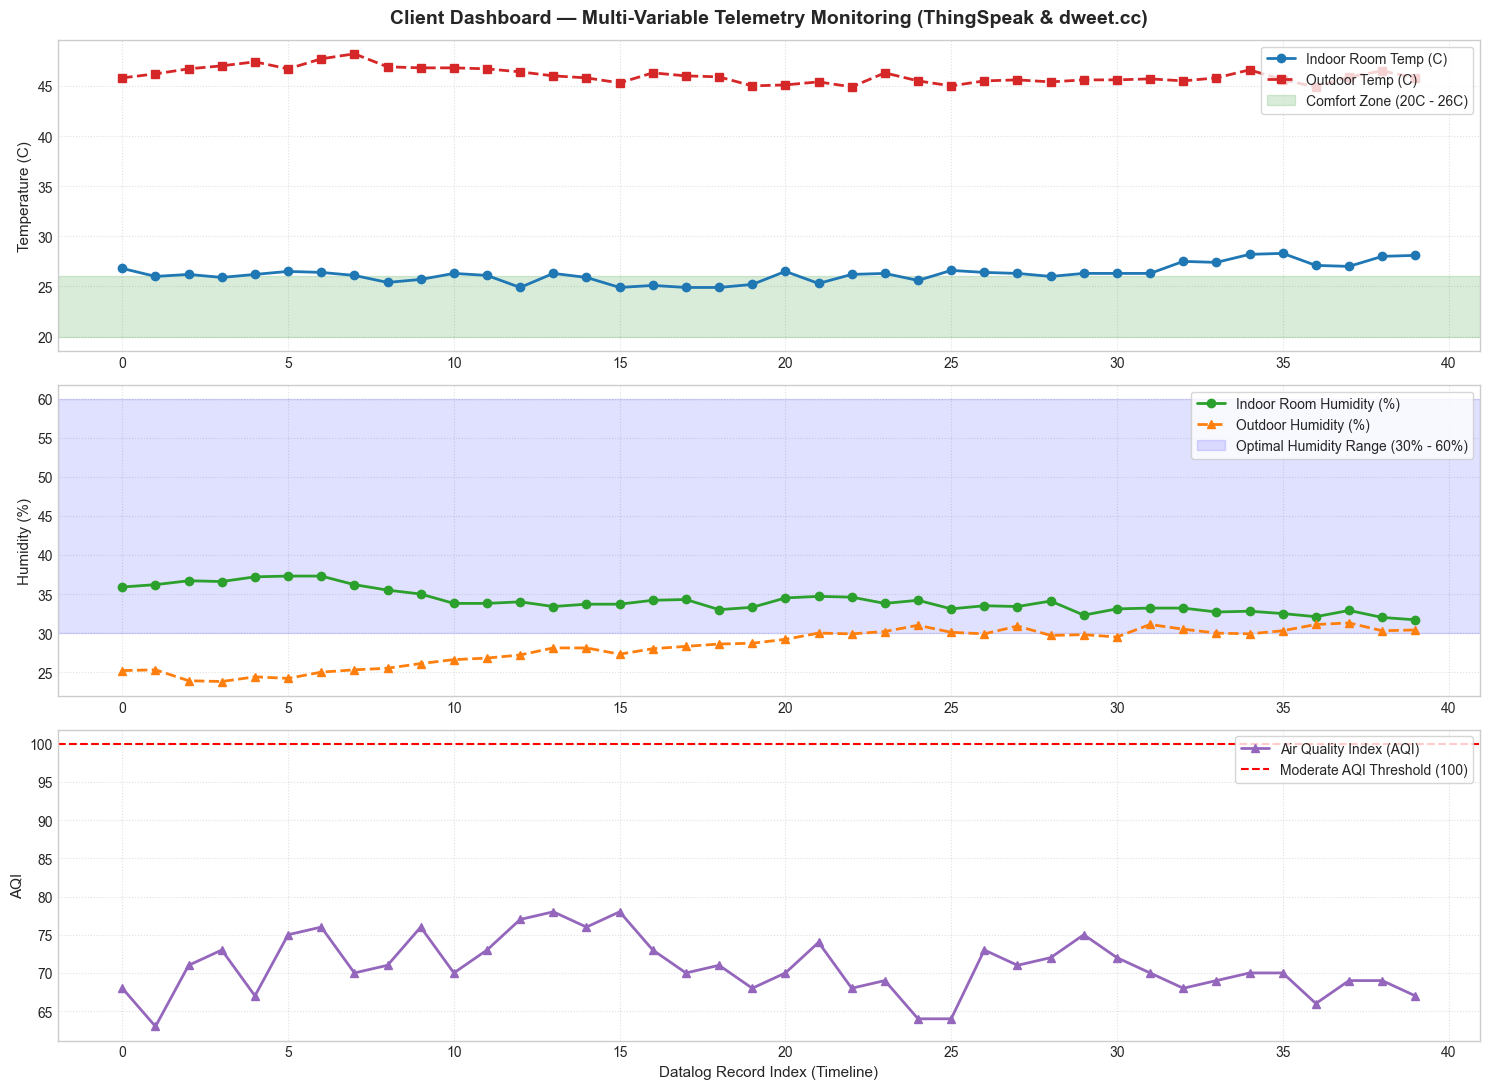


[Saved] Dashboard screenshot saved as 'dashboard_preview.png' for LEB2 submission!

=== Telemetry Summary Statistics (All Fields) ===
           Field  Min  Average  Max
 Indoor Temp (C) 24.9    26.28 28.3
  Indoor Hum (%) 31.7    34.14 37.3
Outdoor Temp (C) 44.9    46.04 48.2
 Outdoor Hum (%) 23.8    28.29 31.3
             AQI 63.0    70.80 78.0
       AC Status  0.0     0.88  1.0


In [6]:
# Generate comprehensive multi-field time-series visualization for Client Devices
df_plot = pd.read_csv(csv_filename, encoding='utf-8-sig').head(40)

plt.figure(figsize=(15, 11))
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Subplot 1: Indoor vs Outdoor Temperature Tracking
plt.subplot(3, 1, 1)
plt.plot(range(len(df_plot)), df_plot['room_temperature'], marker='o', color='#1f77b4', linewidth=2.0, label='Indoor Room Temp (C)')
plt.plot(range(len(df_plot)), df_plot['outdoor_temperature'], marker='s', color='#d62728', linewidth=2.0, linestyle='--', label='Outdoor Temp (C)')
plt.axhspan(20, 26, color='green', alpha=0.15, label='Comfort Zone (20C - 26C)')
plt.title('Client Dashboard — Multi-Variable Telemetry Monitoring (ThingSpeak & dweet.cc)', fontsize=14, fontweight='bold', pad=12)
plt.ylabel('Temperature (C)', fontsize=11)
plt.legend(loc='upper right', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)

# Subplot 2: Indoor vs Outdoor Humidity Tracking
plt.subplot(3, 1, 2)
plt.plot(range(len(df_plot)), df_plot['room_humidity'], marker='o', color='#2ca02c', linewidth=2.0, label='Indoor Room Humidity (%)')
plt.plot(range(len(df_plot)), df_plot['outdoor_humidity'], marker='^', color='#ff7f0e', linewidth=2.0, linestyle='--', label='Outdoor Humidity (%)')
plt.axhspan(30, 60, color='blue', alpha=0.12, label='Optimal Humidity Range (30% - 60%)')
plt.ylabel('Humidity (%)', fontsize=11)
plt.legend(loc='upper right', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)

# Subplot 3: Air Quality Index (AQI) & AC Status
plt.subplot(3, 1, 3)
plt.plot(range(len(df_plot)), df_plot['AQI'], marker='^', color='#9467bd', linewidth=2.0, label='Air Quality Index (AQI)')
plt.axhline(100, color='red', linestyle='--', linewidth=1.5, label='Moderate AQI Threshold (100)')
plt.xlabel('Datalog Record Index (Timeline)', fontsize=11)
plt.ylabel('AQI', fontsize=11)
plt.legend(loc='upper right', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
dashboard_path = 'dashboard_preview.png'
plt.savefig(dashboard_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"\n[Saved] Dashboard screenshot saved as '{dashboard_path}' for LEB2 submission!")

# Summary Statistics across all 6 fields
print("\n=== Telemetry Summary Statistics (All Fields) ===")
summary_stats = pd.DataFrame({
    "Field": ["Indoor Temp (C)", "Indoor Hum (%)", "Outdoor Temp (C)", "Outdoor Hum (%)", "AQI", "AC Status"],
    "Min": [df_plot['room_temperature'].min(), df_plot['room_humidity'].min(), df_plot['outdoor_temperature'].min(), df_plot['outdoor_humidity'].min(), df_plot['AQI'].min(), df_plot['AirCondition_Status'].min()],
    "Average": [round(df_plot['room_temperature'].mean(), 2), round(df_plot['room_humidity'].mean(), 2), round(df_plot['outdoor_temperature'].mean(), 2), round(df_plot['outdoor_humidity'].mean(), 2), round(df_plot['AQI'].mean(), 1), round(df_plot['AirCondition_Status'].mean(), 2)],
    "Max": [df_plot['room_temperature'].max(), df_plot['room_humidity'].max(), df_plot['outdoor_temperature'].max(), df_plot['outdoor_humidity'].max(), df_plot['AQI'].max(), df_plot['AirCondition_Status'].max()]
})
print(summary_stats.to_string(index=False))